# ParkCeleb Dataset — Audio Inventory & Statistics

This notebook scans all downloaded audio files in the ParkCeleb dataset,  
compiles per-subject and per-group statistics, and extracts basic acoustic  
features for an initial characterisation.

### What this notebook computes
1. **Per-subject inventory:** number of recordings, total/avg/min/max duration
2. **Group-level summary:** CN vs PD recording counts, duration distributions
3. **Download completeness:** cross-reference metadata.xlsx against actual files
4. **Basic acoustic features** on a per-file level (F0, energy, etc.)
5. **Group comparison** of acoustic features

---

In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CHANGE THIS to your ParkCeleb root directory              ║
# ╚══════════════════════════════════════════════════════════════╝

PARKCELEB_DIR = '../ParkCeleb'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import librosa
import parselmouth
import os, glob, warnings
from pathlib import Path
from urllib.parse import urlparse, parse_qs

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
})

print('Imports OK')

Imports OK


---
## 1 — Scan the dataset and build a file inventory

Walk every subject folder, find all `.wav` files, and record  
their path, duration, and sample rate without loading the full audio.

In [3]:
# ============================================================
# 1.1  Scan all audio files
# ============================================================

def get_audio_duration(filepath):
    """Get duration and sample rate without loading the full audio."""
    try:
        duration = librosa.get_duration(path=filepath)
        # Get sample rate from the file header
        import soundfile as sf
        info = sf.info(filepath)
        return duration, info.samplerate, info.channels, info.subtype
    except Exception:
        try:
            y, sr = librosa.load(filepath, sr=None, duration=0.1)
            duration = librosa.get_duration(path=filepath)
            return duration, sr, 1, 'unknown'
        except Exception as e:
            return None, None, None, str(e)


def extract_video_id(url):
    """Extract YouTube video ID from URL."""
    if not isinstance(url, str):
        return None
    parsed = urlparse(url.strip())
    if parsed.hostname in ('youtu.be',):
        return parsed.path.lstrip('/').split('/')[0]
    if parsed.hostname in ('www.youtube.com', 'youtube.com', 'm.youtube.com'):
        if parsed.path == '/watch':
            v = parse_qs(parsed.query).get('v')
            return v[0] if v else None
    return None


rows = []
scan_errors = []

for group in ['CN', 'PD']:
    group_dir = os.path.join(PARKCELEB_DIR, group)
    if not os.path.isdir(group_dir):
        print(f'WARNING: {group_dir} not found')
        continue
    
    for subj_name in sorted(os.listdir(group_dir)):
        subj_dir = os.path.join(group_dir, subj_name)
        if not os.path.isdir(subj_dir):
            continue
        
        # Find all wav files recursively under this subject
        wav_files = glob.glob(os.path.join(subj_dir, '**', '*.wav'), recursive=True)
        
        # Also check for other audio formats
        mp3_files = glob.glob(os.path.join(subj_dir, '**', '*.mp3'), recursive=True)
        flac_files = glob.glob(os.path.join(subj_dir, '**', '*.flac'), recursive=True)
        all_audio = wav_files + mp3_files + flac_files
        
        for fpath in sorted(all_audio):
            fname = os.path.basename(fpath)
            # The parent folder name is typically the video ID
            parent_folder = os.path.basename(os.path.dirname(fpath))
            
            dur, sr, ch, subtype = get_audio_duration(fpath)
            
            if dur is not None:
                rows.append({
                    'group': group,
                    'subject': subj_name,
                    'video_id': parent_folder,
                    'filename': fname,
                    'filepath': fpath,
                    'duration_s': dur,
                    'sample_rate': sr,
                    'channels': ch,
                    'format': subtype,
                    'filesize_kb': os.path.getsize(fpath) / 1024,
                })
            else:
                scan_errors.append({'path': fpath, 'error': subtype})

df = pd.DataFrame(rows)

print(f'Scan complete.')
print(f'  Total audio files found : {len(df)}')
print(f'  Scan errors             : {len(scan_errors)}')
if scan_errors:
    for e in scan_errors[:5]:
        print(f"    ERROR: {e['path']} — {e['error']}")

Scan complete.
  Total audio files found : 1462
  Scan errors             : 0


In [4]:
# Quick sanity check
if len(df) == 0:
    print('No audio files found. Check that:')
    print(f'  1. PARKCELEB_DIR is correct: {PARKCELEB_DIR}')
    print(f'  2. Audio files have been downloaded (run parkceleb_download.py first)')
    print(f'  3. Files are in subfolders like ParkCeleb/CN/cn_01/VIDEO_ID/VIDEO_ID.wav')
else:
    print(f'Preview of the inventory:')
    display(df[['group', 'subject', 'video_id', 'duration_s', 'sample_rate', 'filesize_kb']].head(10))

Preview of the inventory:


,group,subject,video_id,duration_s,sample_rate,filesize_kb
0,CN,cn_01,4zHrnCPJTFM,338.872021,48000,63538.580078
1,CN,cn_01,5iEgR25lS5A,115.178667,48000,21596.076172
2,CN,cn_01,EN8ZdMf5oAQ,2089.237333,48000,391732.076172
3,CN,cn_01,FZBZ5KmKdX8,188.174521,48000,35282.798828
4,CN,cn_01,HoBQclABghY,121.962812,48000,22868.103516
5,CN,cn_01,L2tGjae1WD0,616.042667,48000,115508.076172
6,CN,cn_01,OS1lvL63mfc,80.426667,48000,15080.076172
7,CN,cn_01,QwX-bQDsQ5Q,1252.844271,48000,234908.376953
8,CN,cn_01,RjpTsK-WzSw,406.163458,48000,76155.724609
9,CN,cn_01,T-ydfQlVwgs,120.302585,44100,20724.076172


---
## 2 — Per-subject statistics

In [5]:
# ============================================================
# 2.1  Compute per-subject summary
# ============================================================
subj_stats = df.groupby(['group', 'subject']).agg(
    n_recordings  = ('duration_s', 'count'),
    total_dur_s   = ('duration_s', 'sum'),
    mean_dur_s    = ('duration_s', 'mean'),
    median_dur_s  = ('duration_s', 'median'),
    min_dur_s     = ('duration_s', 'min'),
    max_dur_s     = ('duration_s', 'max'),
    std_dur_s     = ('duration_s', 'std'),
    total_size_mb = ('filesize_kb', lambda x: x.sum() / 1024),
).reset_index()

# Convert total duration to minutes for readability
subj_stats['total_dur_min'] = subj_stats['total_dur_s'] / 60

print(f'Per-subject statistics ({len(subj_stats)} subjects):')
print()
display(subj_stats.round(2))

Per-subject statistics (100 subjects):



,group,subject,n_recordings,total_dur_s,mean_dur_s,median_dur_s,min_dur_s,max_dur_s,std_dur_s,total_size_mb,total_dur_min
0,CN,cn_01,18,8539.69,474.43,305.67,80.43,2089.24,510.68,1557.39,142.33
1,CN,cn_02,13,15166.21,1166.63,320.11,68.01,5652.27,1862.41,2777.02,252.77
2,CN,cn_03,12,3818.09,318.17,253.92,134.72,696.47,174.51,695.70,63.63
3,CN,cn_04,10,3948.80,394.88,189.44,51.99,1647.55,497.02,720.70,65.81
4,CN,cn_05,17,11352.73,667.81,475.66,166.58,2535.69,609.35,2055.75,189.21
...,...,...,...,...,...,...,...,...,...,...,...
95,PD,pd_36,22,11571.72,525.99,182.82,45.35,3634.31,804.18,2111.86,192.86
96,PD,pd_37,11,4254.09,386.74,191.82,4.75,1844.45,579.02,778.95,70.90
97,PD,pd_38,8,5844.59,730.57,437.50,128.57,2562.61,780.34,1070.18,97.41
98,PD,pd_39,6,4333.13,722.19,717.46,88.97,1684.45,567.91,793.42,72.22


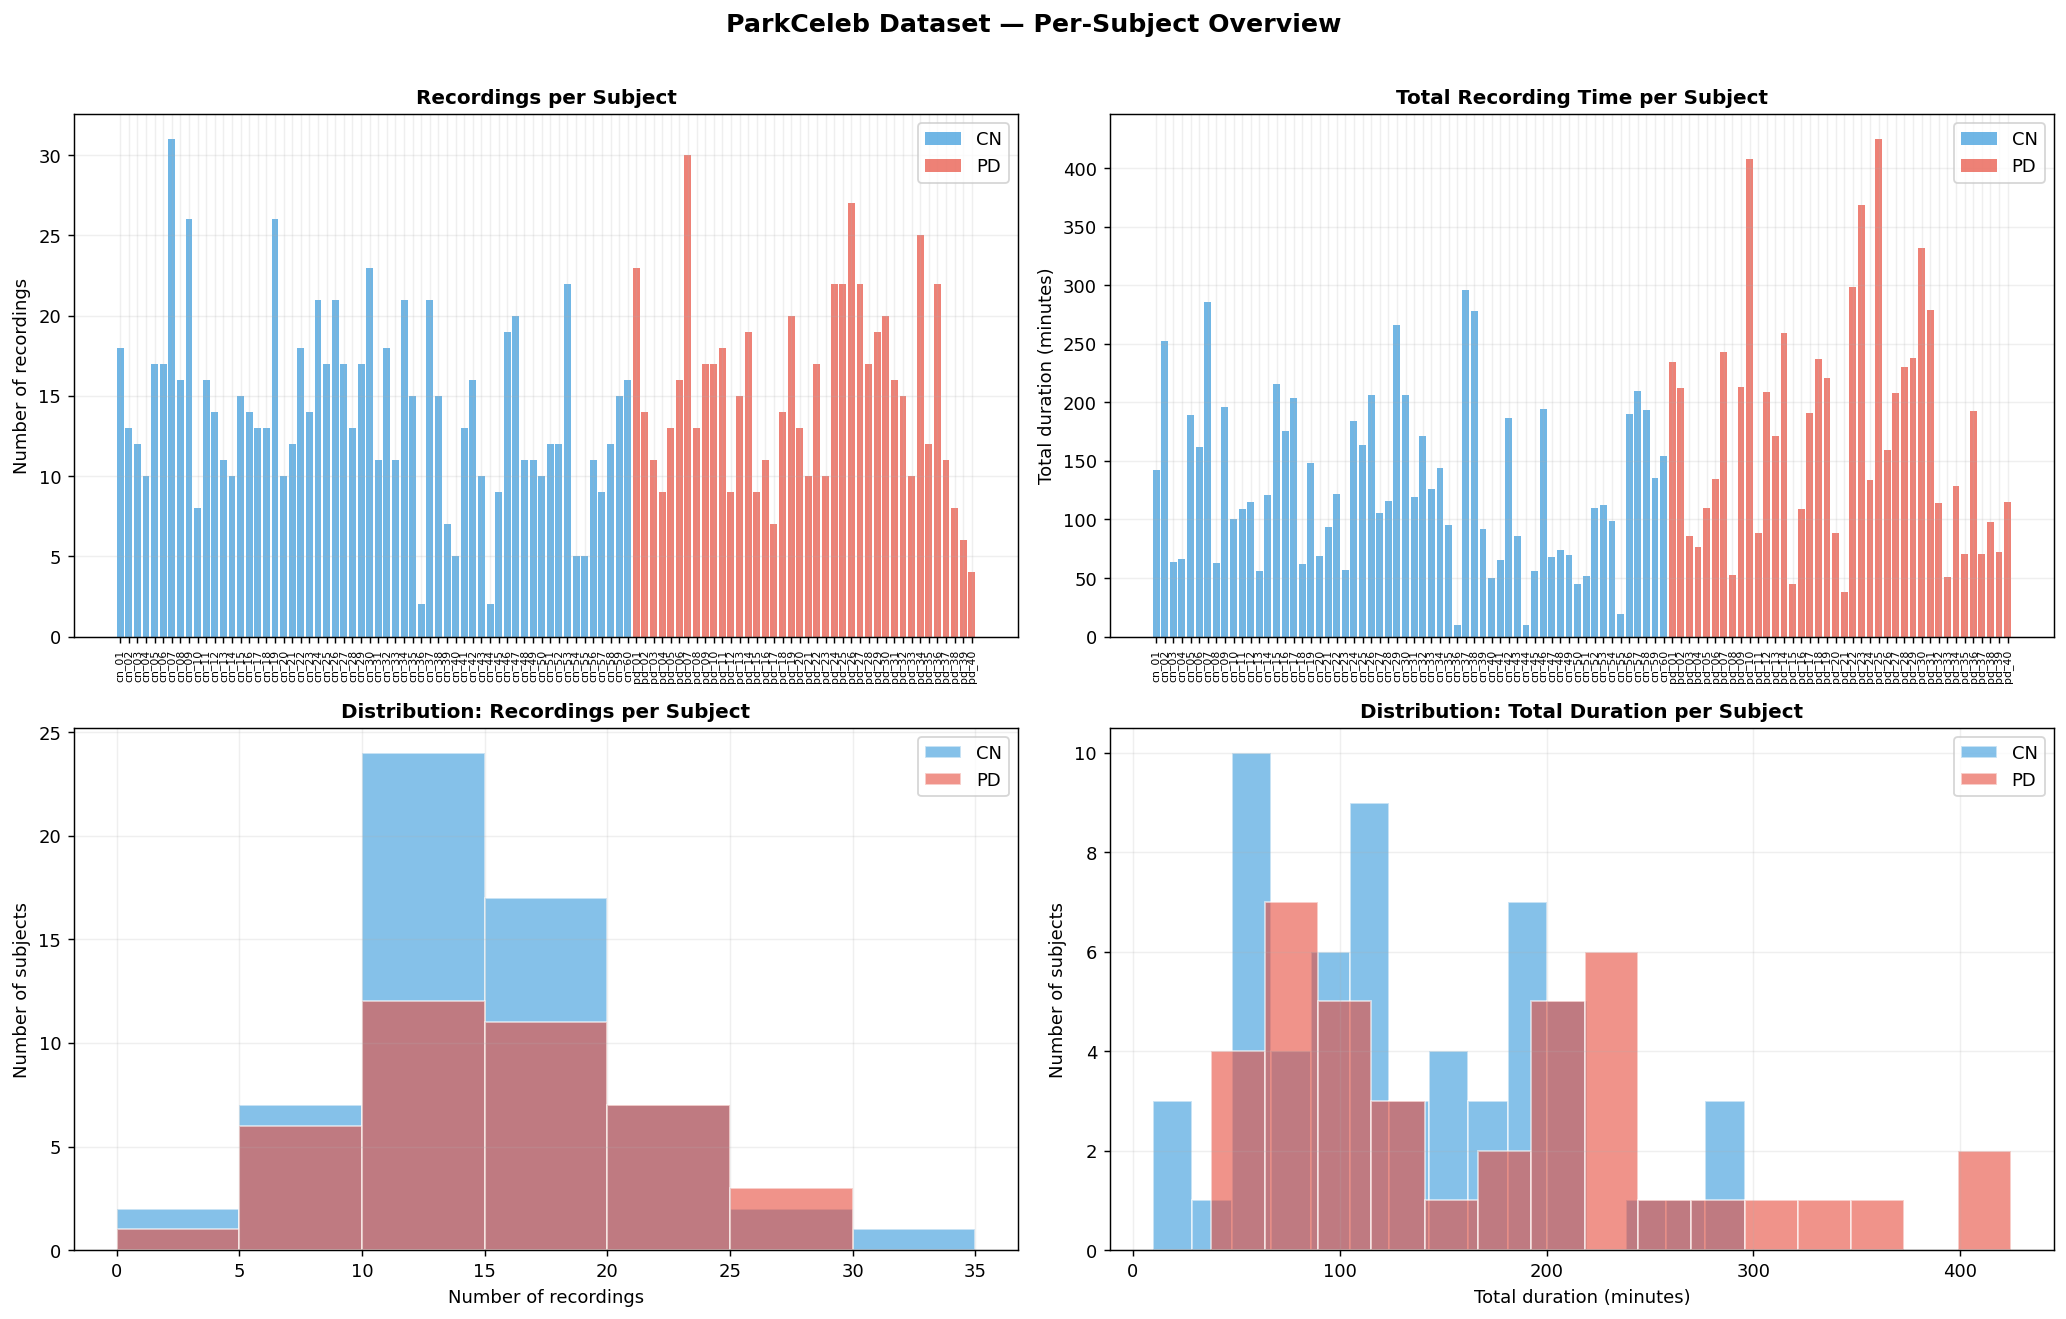

In [6]:
# ============================================================
# 2.2  Visualise per-subject recording counts and durations
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

colors = {'CN': '#3498DB', 'PD': '#E74C3C'}

# --- Top left: Number of recordings per subject ---
ax = axes[0, 0]
for group in ['CN', 'PD']:
    subset = subj_stats[subj_stats['group'] == group]
    ax.bar(subset['subject'], subset['n_recordings'],
           color=colors[group], alpha=0.7, label=group)
ax.set_ylabel('Number of recordings')
ax.set_title('Recordings per Subject')
ax.legend()
ax.tick_params(axis='x', rotation=90, labelsize=6)

# --- Top right: Total duration per subject ---
ax = axes[0, 1]
for group in ['CN', 'PD']:
    subset = subj_stats[subj_stats['group'] == group]
    ax.bar(subset['subject'], subset['total_dur_min'],
           color=colors[group], alpha=0.7, label=group)
ax.set_ylabel('Total duration (minutes)')
ax.set_title('Total Recording Time per Subject')
ax.legend()
ax.tick_params(axis='x', rotation=90, labelsize=6)

# --- Bottom left: Distribution of recording counts ---
ax = axes[1, 0]
for group in ['CN', 'PD']:
    subset = subj_stats[subj_stats['group'] == group]
    ax.hist(subset['n_recordings'], bins=range(0, int(subset['n_recordings'].max()) + 5, 5),
            alpha=0.6, color=colors[group], label=group, edgecolor='white')
ax.set_xlabel('Number of recordings')
ax.set_ylabel('Number of subjects')
ax.set_title('Distribution: Recordings per Subject')
ax.legend()

# --- Bottom right: Distribution of total duration ---
ax = axes[1, 1]
for group in ['CN', 'PD']:
    subset = subj_stats[subj_stats['group'] == group]
    ax.hist(subset['total_dur_min'], bins=15,
            alpha=0.6, color=colors[group], label=group, edgecolor='white')
ax.set_xlabel('Total duration (minutes)')
ax.set_ylabel('Number of subjects')
ax.set_title('Distribution: Total Duration per Subject')
ax.legend()

for a in axes.flatten():
    a.grid(True, alpha=0.2)

plt.suptitle('ParkCeleb Dataset — Per-Subject Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 3 — Group-level summary (CN vs PD)

In [7]:
# ============================================================
# 3.1  Group-level summary table
# ============================================================
group_stats = subj_stats.groupby('group').agg(
    n_subjects       = ('subject', 'count'),
    total_recordings = ('n_recordings', 'sum'),
    total_hours      = ('total_dur_min', lambda x: x.sum() / 60),
    mean_recs_per_subj  = ('n_recordings', 'mean'),
    mean_dur_per_subj   = ('total_dur_min', 'mean'),
    median_dur_per_subj = ('total_dur_min', 'median'),
).round(2)

print('Group-Level Summary')
print('=' * 70)
display(group_stats)

# Overall
total_files = len(df)
total_hours = df['duration_s'].sum() / 3600
total_subjects = subj_stats['subject'].nunique()

print(f'\nOverall dataset:')
print(f'  Subjects          : {total_subjects}')
print(f'  Total recordings  : {total_files}')
print(f'  Total duration    : {total_hours:.1f} hours ({df["duration_s"].sum()/60:.0f} minutes)')
print(f'  Avg per recording : {df["duration_s"].mean():.1f} s')

Group-Level Summary


,n_subjects,total_recordings,total_hours,mean_recs_per_subj,mean_dur_per_subj,median_dur_per_subj
group,,,,,,
CN,60,849,130.41,14.15,130.41,117.25
PD,40,613,116.85,15.32,175.28,164.99



Overall dataset:
  Subjects          : 100
  Total recordings  : 1462
  Total duration    : 247.3 hours (14836 minutes)
  Avg per recording : 608.8 s


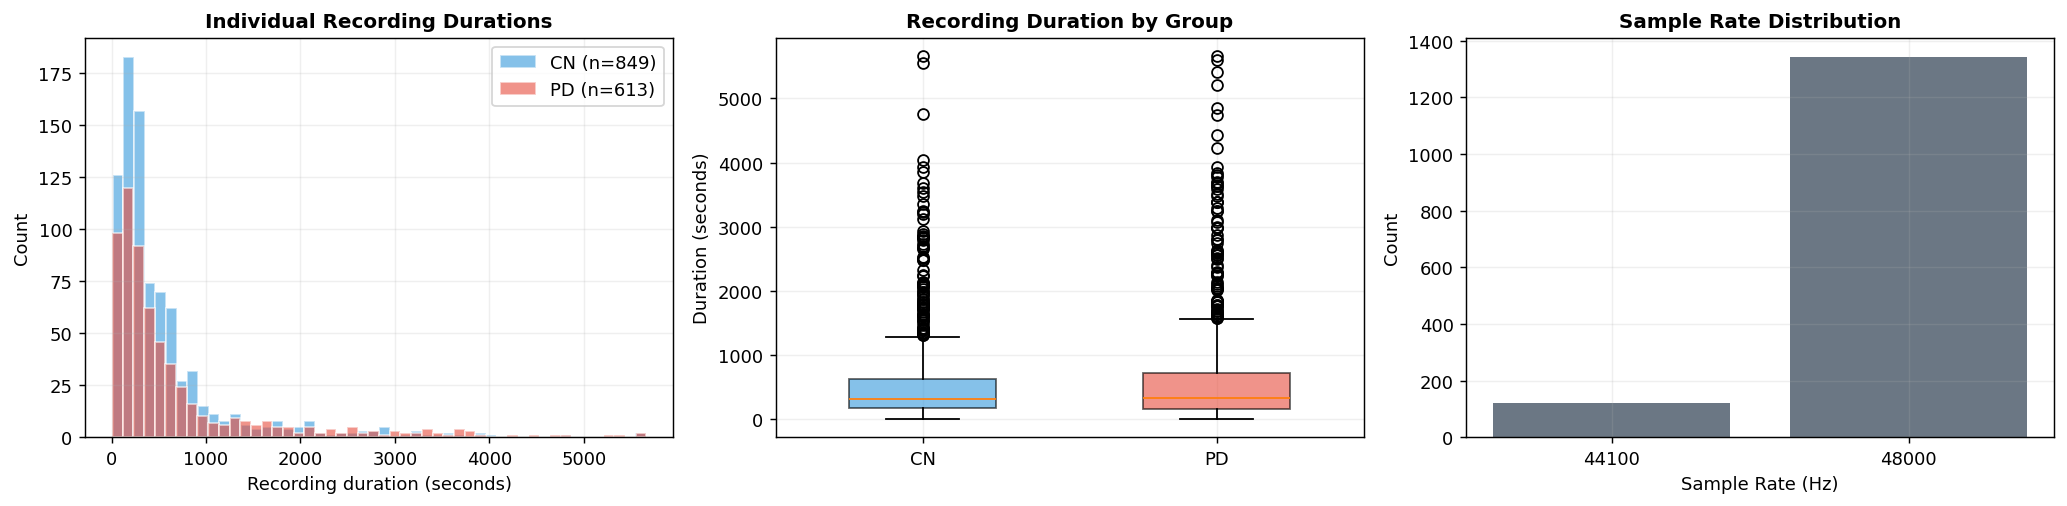

In [8]:
# ============================================================
# 3.2  Recording duration distributions by group
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Distribution of individual recording lengths
ax = axes[0]
for group in ['CN', 'PD']:
    subset = df[df['group'] == group]
    ax.hist(subset['duration_s'], bins=50, alpha=0.6,
            color=colors[group], label=f"{group} (n={len(subset)})", edgecolor='white')
ax.set_xlabel('Recording duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Individual Recording Durations')
ax.legend()

# Box plot of recording durations
ax = axes[1]
cn_dur = df[df['group'] == 'CN']['duration_s']
pd_dur = df[df['group'] == 'PD']['duration_s']
bp = ax.boxplot([cn_dur, pd_dur], labels=['CN', 'PD'], patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor(colors['CN'])
bp['boxes'][1].set_facecolor(colors['PD'])
for box in bp['boxes']:
    box.set_alpha(0.6)
ax.set_ylabel('Duration (seconds)')
ax.set_title('Recording Duration by Group')

# Sample rate distribution
ax = axes[2]
sr_counts = df['sample_rate'].value_counts().sort_index()
ax.bar(sr_counts.index.astype(str), sr_counts.values, color='#2C3E50', alpha=0.7)
ax.set_xlabel('Sample Rate (Hz)')
ax.set_ylabel('Count')
ax.set_title('Sample Rate Distribution')

for a in axes:
    a.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

---
## 4 — Download completeness check

Cross-reference `metadata.xlsx` links against actual downloaded files  
to see how many videos were successfully downloaded.

In [9]:
# ============================================================
# 4.  Download completeness
# ============================================================
completeness = []

for group in ['CN', 'PD']:
    group_dir = os.path.join(PARKCELEB_DIR, group)
    if not os.path.isdir(group_dir):
        continue
    for subj_name in sorted(os.listdir(group_dir)):
        subj_dir = os.path.join(group_dir, subj_name)
        if not os.path.isdir(subj_dir):
            continue
        xlsx_path = os.path.join(subj_dir, 'metadata.xlsx')
        if not os.path.isfile(xlsx_path):
            continue
        
        try:
            meta_df = pd.read_excel(xlsx_path)
        except Exception:
            continue
        
        # Find link column
        link_col = None
        for col in meta_df.columns:
            if col.strip().lower() in ('link', 'links', 'url', 'youtube', 'video_link'):
                link_col = col
                break
        if link_col is None:
            for col in meta_df.columns:
                sample = meta_df[col].dropna().astype(str)
                if sample.str.contains('youtube|youtu', case=False).any():
                    link_col = col
                    break
        
        n_expected = 0
        n_downloaded = 0
        
        if link_col is not None:
            for url in meta_df[link_col].dropna():
                vid = extract_video_id(str(url))
                if vid:
                    n_expected += 1
                    vid_dir = os.path.join(subj_dir, vid)
                    if os.path.isdir(vid_dir):
                        audio_files = [f for f in os.listdir(vid_dir)
                                       if f.endswith(('.wav', '.mp3', '.flac'))]
                        if audio_files:
                            n_downloaded += 1
        
        completeness.append({
            'group': group,
            'subject': subj_name,
            'expected': n_expected,
            'downloaded': n_downloaded,
            'missing': n_expected - n_downloaded,
            'pct': (n_downloaded / n_expected * 100) if n_expected > 0 else 0,
        })

comp_df = pd.DataFrame(completeness)

if len(comp_df) > 0:
    total_expected = comp_df['expected'].sum()
    total_downloaded = comp_df['downloaded'].sum()
    total_missing = comp_df['missing'].sum()
    
    print(f'Download Completeness')
    print(f'=====================')
    print(f'  Expected (from metadata) : {total_expected}')
    print(f'  Downloaded               : {total_downloaded}')
    print(f'  Missing                  : {total_missing}')
    print(f'  Completeness             : {total_downloaded/total_expected:.1%}' if total_expected > 0 else '')
    
    # Show subjects with missing downloads
    missing = comp_df[comp_df['missing'] > 0].sort_values('missing', ascending=False)
    if len(missing) > 0:
        print(f'\n  Subjects with missing downloads ({len(missing)}):')
        for _, row in missing.head(15).iterrows():
            print(f"    {row['subject']:>10s} ({row['group']}): {row['downloaded']}/{row['expected']} downloaded ({row['missing']} missing)")
        if len(missing) > 15:
            print(f'    ... and {len(missing)-15} more')
else:
    print('No metadata.xlsx files found — skipping completeness check.')

No metadata.xlsx files found — skipping completeness check.


---
## 5 — Basic acoustic feature extraction (sampled)

Running full feature extraction on thousands of files takes time.  
Here we sample a subset (configurable) to get an initial acoustic profile.

In [10]:
# ============================================================
# 5.1  Extract acoustic features from a subset
# ============================================================

# How many files per subject to sample (set to None for ALL files)
MAX_FILES_PER_SUBJECT = 3

def extract_basic_features(filepath):
    """Extract summary acoustic features from one audio file."""
    try:
        y, sr = librosa.load(filepath, sr=16000)  # resample to 16kHz for consistency
        duration = len(y) / sr
        
        if duration < 2.0:  # skip very short files
            return None
        
        fl = int(sr * 0.025)
        hl = int(sr * 0.010)
        
        # RMS Energy
        rms = librosa.feature.rms(y=y, frame_length=fl, hop_length=hl)[0]
        rms_db = 20 * np.log10(rms + 1e-10)
        
        # ZCR
        zcr = librosa.feature.zero_crossing_rate(y, frame_length=fl, hop_length=hl)[0]
        
        # Spectral Centroid
        cent = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=hl)[0]
        
        # F0 via Praat
        snd = parselmouth.Sound(y.astype(np.float64), sampling_frequency=sr)
        pitch = snd.to_pitch(time_step=0.01, pitch_floor=75.0, pitch_ceiling=500.0)
        f0 = pitch.selected_array['frequency']
        f0_voiced = f0[f0 > 0]
        
        # Intensity via Praat
        intensity = snd.to_intensity(time_step=0.01, minimum_pitch=75.0)
        int_vals = intensity.values[0]
        
        # MFCCs
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=fl, hop_length=hl)
        
        # Simple SNR estimate
        sorted_rms_db = np.sort(rms_db)
        noise_floor = np.median(sorted_rms_db[:max(1, len(sorted_rms_db)//10)])
        threshold = noise_floor + 15
        speech_mask_frames = rms_db >= threshold
        speech_frac = speech_mask_frames.mean()
        
        feats = {
            'duration_s': duration,
            'rms_mean': rms.mean(),
            'rms_std': rms.std(),
            'rms_db_mean': rms_db.mean(),
            'rms_db_std': rms_db.std(),
            'zcr_mean': zcr.mean(),
            'zcr_std': zcr.std(),
            'centroid_mean': cent.mean(),
            'centroid_std': cent.std(),
            'f0_mean': f0_voiced.mean() if len(f0_voiced) > 0 else np.nan,
            'f0_std': f0_voiced.std() if len(f0_voiced) > 0 else np.nan,
            'f0_range': (f0_voiced.max() - f0_voiced.min()) if len(f0_voiced) > 1 else np.nan,
            'voicing_frac': len(f0_voiced) / len(f0) if len(f0) > 0 else np.nan,
            'intensity_mean': int_vals.mean(),
            'intensity_std': int_vals.std(),
            'speech_frac': speech_frac,
        }
        
        for i in range(13):
            feats[f'mfcc{i}_mean'] = mfccs[i].mean()
        
        return feats
    except Exception as e:
        return None


# Sample files
sampled_rows = []

for (group, subject), subj_df in df.groupby(['group', 'subject']):
    files_to_process = subj_df
    if MAX_FILES_PER_SUBJECT is not None and len(files_to_process) > MAX_FILES_PER_SUBJECT:
        files_to_process = files_to_process.sample(n=MAX_FILES_PER_SUBJECT, random_state=42)
    
    for _, row in files_to_process.iterrows():
        sampled_rows.append(row)

print(f'Extracting acoustic features from {len(sampled_rows)} files '
      f'(max {MAX_FILES_PER_SUBJECT} per subject)...')

feat_rows = []
for i, row in enumerate(sampled_rows):
    feats = extract_basic_features(row['filepath'])
    if feats is not None:
        feats['group'] = row['group']
        feats['subject'] = row['subject']
        feats['video_id'] = row['video_id']
        feats['filename'] = row['filename']
        feat_rows.append(feats)
    
    if (i + 1) % 20 == 0:
        print(f'  {i+1}/{len(sampled_rows)} done...')

feat_df = pd.DataFrame(feat_rows)
print(f'\nDone. {len(feat_df)} files processed successfully.')

Extracting acoustic features from 298 files (max 3 per subject)...
  20/298 done...
  40/298 done...
  60/298 done...
  80/298 done...
  100/298 done...
  120/298 done...
  140/298 done...
  160/298 done...
  180/298 done...
  200/298 done...
  220/298 done...
  240/298 done...
  260/298 done...
  280/298 done...

Done. 298 files processed successfully.


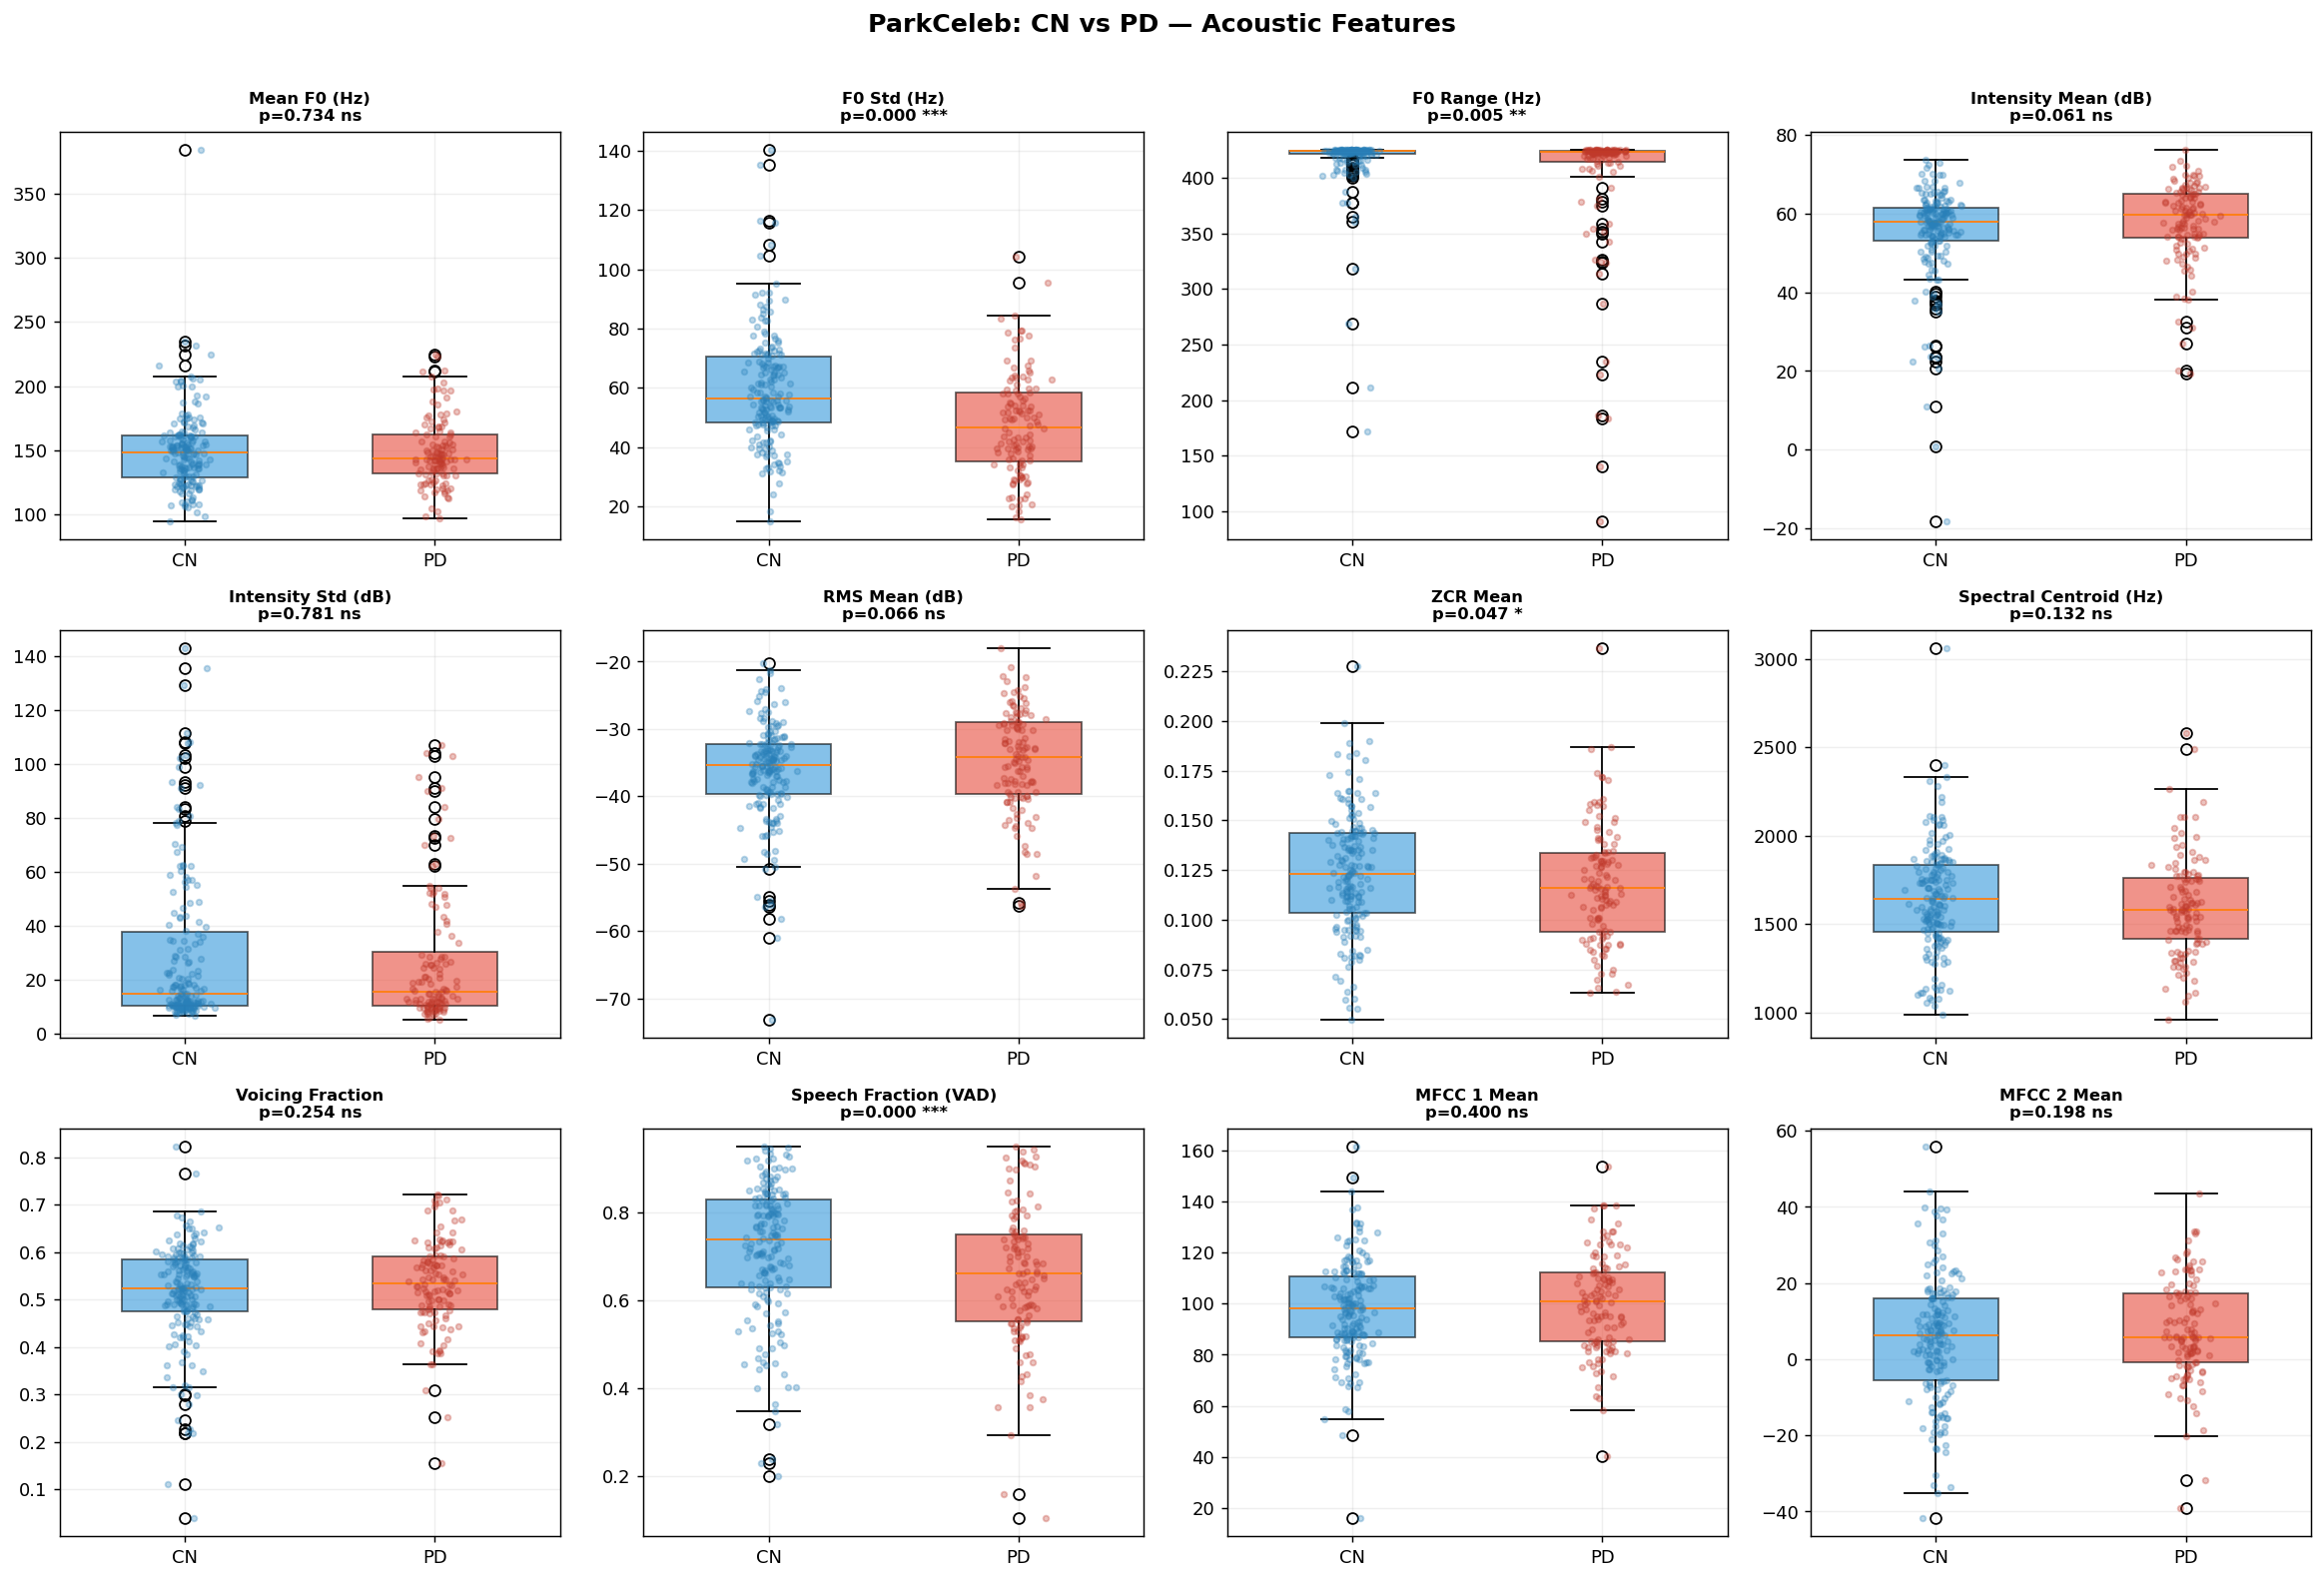

In [11]:
# ============================================================
# 5.2  Group comparison box plots
# ============================================================
if len(feat_df) > 0:
    compare = [
        ('f0_mean',        'Mean F0 (Hz)'),
        ('f0_std',         'F0 Std (Hz)'),
        ('f0_range',       'F0 Range (Hz)'),
        ('intensity_mean', 'Intensity Mean (dB)'),
        ('intensity_std',  'Intensity Std (dB)'),
        ('rms_db_mean',    'RMS Mean (dB)'),
        ('zcr_mean',       'ZCR Mean'),
        ('centroid_mean',  'Spectral Centroid (Hz)'),
        ('voicing_frac',   'Voicing Fraction'),
        ('speech_frac',    'Speech Fraction (VAD)'),
        ('mfcc1_mean',     'MFCC 1 Mean'),
        ('mfcc2_mean',     'MFCC 2 Mean'),
    ]
    
    from scipy import stats as sp_stats
    
    fig, axes = plt.subplots(3, 4, figsize=(18, 12))
    axes = axes.flatten()
    
    for idx, (feat, label) in enumerate(compare):
        ax = axes[idx]
        cn = feat_df[feat_df['group'] == 'CN'][feat].dropna()
        pd_g = feat_df[feat_df['group'] == 'PD'][feat].dropna()
        
        bp = ax.boxplot([cn, pd_g], labels=['CN', 'PD'], patch_artist=True, widths=0.5)
        bp['boxes'][0].set_facecolor('#3498DB')
        bp['boxes'][1].set_facecolor('#E74C3C')
        for box in bp['boxes']:
            box.set_alpha(0.6)
        
        # Scatter overlay
        ax.scatter(np.ones(len(cn)) + np.random.normal(0, 0.04, len(cn)),
                   cn, alpha=0.3, s=10, color='#2980B9', zorder=3)
        ax.scatter(2*np.ones(len(pd_g)) + np.random.normal(0, 0.04, len(pd_g)),
                   pd_g, alpha=0.3, s=10, color='#C0392B', zorder=3)
        
        # Mann-Whitney U test
        if len(cn) > 2 and len(pd_g) > 2:
            _, p = sp_stats.mannwhitneyu(cn, pd_g, alternative='two-sided')
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            ax.set_title(f'{label}\np={p:.3f} {sig}', fontsize=9)
        else:
            ax.set_title(label, fontsize=9)
        
        ax.grid(True, alpha=0.2)
    
    plt.suptitle('ParkCeleb: CN vs PD — Acoustic Features',
                 fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('No features extracted — skipping comparison plots.')

In [12]:
# ============================================================
# 5.3  Effect size table
# ============================================================
if len(feat_df) > 0:
    def cohens_d(g1, g2):
        n1, n2 = len(g1), len(g2)
        pooled = np.sqrt(((n1-1)*g1.var() + (n2-1)*g2.var()) / (n1+n2-2))
        return (g1.mean() - g2.mean()) / pooled if pooled > 0 else 0
    
    print(f'{"Feature":<22s} {"CN mean":>10s} {"PD mean":>10s} {"Cohen d":>10s} {"p-value":>10s} {"Sig":>5s}')
    print('-' * 72)
    
    for feat, label in compare:
        cn = feat_df[feat_df['group'] == 'CN'][feat].dropna()
        pd_g = feat_df[feat_df['group'] == 'PD'][feat].dropna()
        if len(cn) < 3 or len(pd_g) < 3:
            continue
        d = cohens_d(cn, pd_g)
        _, p = sp_stats.mannwhitneyu(cn, pd_g, alternative='two-sided')
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f'{feat:<22s} {cn.mean():>10.3f} {pd_g.mean():>10.3f} {d:>10.3f} {p:>10.4f} {sig:>5s}')

Feature                   CN mean    PD mean    Cohen d    p-value   Sig
------------------------------------------------------------------------
f0_mean                   149.992    148.525      0.049     0.7344      
f0_std                     59.709     47.657      0.648     0.0000   ***
f0_range                  416.484    400.752      0.359     0.0052    **
intensity_mean             55.256     57.713     -0.214     0.0614      
intensity_std              29.281     26.634      0.097     0.7813      
rms_db_mean               -36.430    -34.721     -0.227     0.0661      
zcr_mean                    0.124      0.118      0.197     0.0472     *
centroid_mean            1643.197   1599.560      0.149     0.1318      
voicing_frac                0.514      0.533     -0.187     0.2538      
speech_frac                 0.713      0.655      0.372     0.0004   ***
mfcc1_mean                 98.120    100.215     -0.109     0.3996      
mfcc2_mean                  5.257      7.759     -0

---
## 6 — Dataset summary card

In [13]:
# ============================================================
# 6.  Print a summary card for presentation
# ============================================================
cn_stats = subj_stats[subj_stats['group'] == 'CN']
pd_stats = subj_stats[subj_stats['group'] == 'PD']

cn_files = df[df['group'] == 'CN']
pd_files = df[df['group'] == 'PD']

print('┌────────────────────────────────────────────────────────────────┐')
print('│                ParkCeleb Dataset Summary                      │')
print('├────────────────────────┬───────────────┬───────────────────────┤')
print(f'│                        │ {"CN":^13s} │ {"PD":^21s} │')
print('├────────────────────────┼───────────────┼───────────────────────┤')
print(f'│  Subjects              │ {len(cn_stats):>13d} │ {len(pd_stats):>21d} │')
print(f'│  Total recordings      │ {len(cn_files):>13d} │ {len(pd_files):>21d} │')
print(f'│  Total duration (hrs)  │ {cn_files["duration_s"].sum()/3600:>13.1f} │ {pd_files["duration_s"].sum()/3600:>21.1f} │')
print(f'│  Avg recs / subject    │ {cn_stats["n_recordings"].mean():>13.1f} │ {pd_stats["n_recordings"].mean():>21.1f} │')
print(f'│  Avg recording len (s) │ {cn_files["duration_s"].mean():>13.1f} │ {pd_files["duration_s"].mean():>21.1f} │')
print(f'│  Median rec len (s)    │ {cn_files["duration_s"].median():>13.1f} │ {pd_files["duration_s"].median():>21.1f} │')
print(f'│  Min recording (s)     │ {cn_files["duration_s"].min():>13.1f} │ {pd_files["duration_s"].min():>21.1f} │')
print(f'│  Max recording (s)     │ {cn_files["duration_s"].max():>13.1f} │ {pd_files["duration_s"].max():>21.1f} │')
print('├────────────────────────┼───────────────┼───────────────────────┤')
sr_mode = df['sample_rate'].mode().iloc[0] if len(df) > 0 else 'N/A'
print(f'│  Most common SR        │ {str(sr_mode)+" Hz":>13s} │                       │')
print(f'│  Total size (GB)       │ {df["filesize_kb"].sum()/1024/1024:>13.2f} │                       │')
print('└────────────────────────┴───────────────┴───────────────────────┘')

┌────────────────────────────────────────────────────────────────┐
│                ParkCeleb Dataset Summary                      │
├────────────────────────┬───────────────┬───────────────────────┤
│                        │      CN       │          PD           │
├────────────────────────┼───────────────┼───────────────────────┤
│  Subjects              │            60 │                    40 │
│  Total recordings      │           849 │                   613 │
│  Total duration (hrs)  │         130.4 │                 116.9 │
│  Avg recs / subject    │          14.2 │                  15.3 │
│  Avg recording len (s) │         553.0 │                 686.2 │
│  Median rec len (s)    │         316.0 │                 339.2 │
│  Min recording (s)     │          11.9 │                   4.7 │
│  Max recording (s)     │        5652.3 │                5660.3 │
├────────────────────────┼───────────────┼───────────────────────┤
│  Most common SR        │      48000 Hz │                     

In [14]:
# ============================================================
# 7.  Save everything to CSV
# ============================================================
df.to_csv('parkceleb_file_inventory.csv', index=False)
subj_stats.to_csv('parkceleb_subject_stats.csv', index=False)
if len(feat_df) > 0:
    feat_df.to_csv('parkceleb_acoustic_features.csv', index=False)
if len(comp_df) > 0:
    comp_df.to_csv('parkceleb_completeness.csv', index=False)

print('Saved:')
print(f'  parkceleb_file_inventory.csv     ({len(df)} files)')
print(f'  parkceleb_subject_stats.csv      ({len(subj_stats)} subjects)')
if len(feat_df) > 0:
    print(f'  parkceleb_acoustic_features.csv  ({len(feat_df)} files with features)')
if len(comp_df) > 0:
    print(f'  parkceleb_completeness.csv       ({len(comp_df)} subjects checked)')

Saved:
  parkceleb_file_inventory.csv     (1462 files)
  parkceleb_subject_stats.csv      (100 subjects)
  parkceleb_acoustic_features.csv  (298 files with features)
